# Deep Ensemble: Student-t (ν=3) × 5 Seeds

**Uncertainty decomposition into aleatoric and epistemic components.**

$$\mu_{\text{ens}}(x) = \frac{1}{M}\sum_{m=1}^{M}\mu_m(x)$$

$$\text{Aleatoric}(x) = \frac{1}{M}\sum_{m=1}^{M}\sigma_m^2(x)$$

$$\text{Epistemic}(x) = \frac{1}{M}\sum_{m=1}^{M}\bigl(\mu_m(x) - \mu_{\text{ens}}(x)\bigr)^2$$

$$\text{Total Var}(x) = \text{Aleatoric}(x) + \text{Epistemic}(x)$$

In [1]:
import sys, warnings, logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy import stats as sp_stats

sys.path.insert(0, ".")
from uapp.data import load_cached_embeddings, make_loader
from uapp.heads import build_head
from uapp.train import train_head, TrainConfig
from uapp.evaluate import (
    evaluate_head,
    compute_coverage_curve,
    compute_ice,
    compute_rmse,
    compute_mae,
    compute_gaussian_nll,
    gather_probabilistic_predictions,
    plot_reliability_diagram,
)

warnings.filterwarnings("ignore", category=FutureWarning)
logging.basicConfig(level=logging.INFO, format="%(name)s | %(message)s")
log = logging.getLogger("ensemble")

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 10,
    "legend.fontsize": 8, "figure.facecolor": "white",
})

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

CACHE_DIR = Path("cache")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

BATCH_SIZE = 256
M = 5
SEEDS = [42, 123, 456, 789, 1024]

print(f"Device: {DEVICE}  |  Ensemble size: {M}  |  Seeds: {SEEDS}")

Device: mps  |  Ensemble size: 5  |  Seeds: [42, 123, 456, 789, 1024]


## Load Data (A3, 680-d)

In [2]:
splits, meta = load_cached_embeddings(CACHE_DIR / "t2837_embeddings_v2.pt")
dim = meta.get("d", splits["train"][0].shape[-1])

loaders = {
    name: make_loader(X, y, batch_size=BATCH_SIZE, shuffle=(name == "train"))
    for name, (X, y) in splits.items()
}

meta_df = pd.read_csv(CACHE_DIR / "t2837_metadata.csv")
test_meta = meta_df[meta_df["split"] == "test"].reset_index(drop=True)

print(f"Input dim: {dim}")
print(f"Train: {splits['train'][0].shape[0]}  Val: {splits['val'][0].shape[0]}  "
      f"Test: {splits['test'][0].shape[0]}")

Input dim: 680
Train: 1395  Val: 1019  Test: 170


## Train 5 Members

In [3]:
cfg = TrainConfig(
    max_epochs=300,
    lr=1e-3,
    weight_decay=1e-5,
    patience=30,
    loss_type="student_t",
    student_t_nu=3.0,
)

trained_heads = []
single_results = []

for i, seed in enumerate(SEEDS):
    print(f"\n{'='*55}")
    print(f"  Member {i+1}/{M}  —  seed={seed}")
    print(f"{'='*55}")

    torch.manual_seed(seed)
    np.random.seed(seed)
    loaders["train"] = make_loader(
        splits["train"][0], splits["train"][1],
        batch_size=BATCH_SIZE, shuffle=True,
    )

    head = build_head("two_head_nll", d_in=dim)
    head, history = train_head(head, loaders["train"], loaders["val"],
                               config=cfg, device=DEVICE)

    result = evaluate_head(head, loaders["test"], DEVICE,
                           head_name=f"seed_{seed}")
    log.info(result.pretty())

    trained_heads.append(head)
    single_results.append(result)


  Member 1/5  —  seed=42


uapp.train | [train] epoch   1 | train 2.0944 | val 2.1038 | best 2.1038 @ ep 1
uapp.train | [train] epoch  10 | train 1.5601 | val 2.0831 | best 2.0337 @ ep 2
uapp.train | [train] epoch  20 | train 1.3384 | val 2.1589 | best 2.0337 @ ep 2
uapp.train | [train] epoch  30 | train 1.1538 | val 2.1934 | best 2.0337 @ ep 2
uapp.train | [train] early stop at epoch 32 (best 2.0337 @ ep 2)
ensemble | [seed_42] n=170
  RMSE : 1.5052
  MAE  : 1.1228
  NLL  : 1.8629
  ICE  : 0.0280
  cov: 0.50→0.482, 0.80→0.841, 0.90→0.912, 0.95→0.929
uapp.train | [train] epoch   1 | train 2.0701 | val 2.0843 | best 2.0843 @ ep 1



  Member 2/5  —  seed=123


uapp.train | [train] epoch  10 | train 1.5514 | val 2.1096 | best 2.0324 @ ep 2
uapp.train | [train] epoch  20 | train 1.3122 | val 2.1910 | best 2.0324 @ ep 2
uapp.train | [train] epoch  30 | train 1.1354 | val 2.2524 | best 2.0324 @ ep 2
uapp.train | [train] early stop at epoch 32 (best 2.0324 @ ep 2)
ensemble | [seed_123] n=170
  RMSE : 1.5063
  MAE  : 1.1194
  NLL  : 1.8537
  ICE  : 0.0295
  cov: 0.50→0.488, 0.80→0.841, 0.90→0.918, 0.95→0.929
uapp.train | [train] epoch   1 | train 2.1095 | val 2.0993 | best 2.0993 @ ep 1



  Member 3/5  —  seed=456


uapp.train | [train] epoch  10 | train 1.5735 | val 2.0638 | best 2.0329 @ ep 2
uapp.train | [train] epoch  20 | train 1.3624 | val 2.1597 | best 2.0329 @ ep 2
uapp.train | [train] epoch  30 | train 1.1612 | val 2.2693 | best 2.0329 @ ep 2
uapp.train | [train] early stop at epoch 32 (best 2.0329 @ ep 2)
ensemble | [seed_456] n=170
  RMSE : 1.5222
  MAE  : 1.1329
  NLL  : 1.8994
  ICE  : 0.0283
  cov: 0.50→0.488, 0.80→0.835, 0.90→0.906, 0.95→0.929
uapp.train | [train] epoch   1 | train 2.0959 | val 2.0879 | best 2.0879 @ ep 1



  Member 4/5  —  seed=789


uapp.train | [train] epoch  10 | train 1.5707 | val 2.0894 | best 2.0324 @ ep 2
uapp.train | [train] epoch  20 | train 1.3336 | val 2.2116 | best 2.0324 @ ep 2
uapp.train | [train] epoch  30 | train 1.1514 | val 2.2288 | best 2.0324 @ ep 2
uapp.train | [train] early stop at epoch 32 (best 2.0324 @ ep 2)
ensemble | [seed_789] n=170
  RMSE : 1.5112
  MAE  : 1.1322
  NLL  : 1.8483
  ICE  : 0.0331
  cov: 0.50→0.506, 0.80→0.835, 0.90→0.924, 0.95→0.929
uapp.train | [train] epoch   1 | train 2.0674 | val 2.0810 | best 2.0810 @ ep 1



  Member 5/5  —  seed=1024


uapp.train | [train] epoch  10 | train 1.5617 | val 2.0914 | best 2.0336 @ ep 2
uapp.train | [train] epoch  20 | train 1.3425 | val 2.1047 | best 2.0336 @ ep 2
uapp.train | [train] epoch  30 | train 1.1856 | val 2.2788 | best 2.0336 @ ep 2
uapp.train | [train] early stop at epoch 32 (best 2.0336 @ ep 2)
ensemble | [seed_1024] n=170
  RMSE : 1.5177
  MAE  : 1.1232
  NLL  : 1.8553
  ICE  : 0.0325
  cov: 0.50→0.524, 0.80→0.847, 0.90→0.924, 0.95→0.935


## Gather Per-Member Predictions

In [4]:
all_mu = []
all_sigma = []

for head in trained_heads:
    mu, sigma, y = gather_probabilistic_predictions(head, loaders["test"], DEVICE)
    all_mu.append(mu)
    all_sigma.append(sigma)

all_mu = np.stack(all_mu)        # (M, N_test)
all_sigma = np.stack(all_sigma)  # (M, N_test)
y_test = y                       # (N_test,)

print(f"Predictions shape: {all_mu.shape}")

Predictions shape: (5, 170)


## Ensemble Combination

$$\sigma_{\text{ens}} = \sqrt{\text{Aleatoric} + \text{Epistemic}}$$

In [5]:
mu_ens = all_mu.mean(axis=0)
aleatoric = (all_sigma ** 2).mean(axis=0)
epistemic = ((all_mu - mu_ens[None, :]) ** 2).mean(axis=0)
total_var = aleatoric + epistemic
sigma_ens = np.sqrt(total_var)

sigma_alea = np.sqrt(aleatoric)
sigma_epi = np.sqrt(epistemic)
errors = np.abs(y_test - mu_ens)

print(f"Ensemble RMSE:        {compute_rmse(mu_ens, y_test):.4f}")
print(f"Ensemble MAE:         {compute_mae(mu_ens, y_test):.4f}")
print(f"Ensemble NLL:         {compute_gaussian_nll(mu_ens, sigma_ens, y_test):.4f}")
ice_ens, cov_ens = compute_ice(mu_ens, sigma_ens, y_test)
print(f"Ensemble ICE:         {ice_ens:.4f}")
print(f"Ensemble cov@90:      {cov_ens.get('0.90', 'N/A')}")
print(f"corr(σ_ens, |error|): {np.corrcoef(sigma_ens, errors)[0,1]:.4f}")
print(f"Mean aleatoric σ:     {sigma_alea.mean():.4f}")
print(f"Mean epistemic σ:     {sigma_epi.mean():.4f}")
print(f"Epistemic fraction:   {(epistemic / total_var.clip(1e-12)).mean():.2%}")

Ensemble RMSE:        1.5116
Ensemble MAE:         1.1254
Ensemble NLL:         1.8592
Ensemble ICE:         0.0303
Ensemble cov@90:      0.9176470588235294
corr(σ_ens, |error|): 0.0012
Mean aleatoric σ:     1.3791
Mean epistemic σ:     0.0481
Epistemic fraction:   0.14%


## Summary: Single Members vs Ensemble

In [6]:
rows = []
for i, r in enumerate(single_results):
    rows.append({
        "model": r.head_name,
        "RMSE": round(r.rmse, 4),
        "MAE": round(r.mae, 4),
        "NLL": round(r.nll, 4) if r.nll else None,
        "ICE": round(r.ice, 4) if r.ice else None,
        "cov@90": round(r.coverage["0.90"], 3) if r.coverage else None,
    })
rows.append({
    "model": "ENSEMBLE (M=5)",
    "RMSE": round(compute_rmse(mu_ens, y_test), 4),
    "MAE": round(compute_mae(mu_ens, y_test), 4),
    "NLL": round(compute_gaussian_nll(mu_ens, sigma_ens, y_test), 4),
    "ICE": round(ice_ens, 4),
    "cov@90": round(float(cov_ens.get("0.90", 0)), 3),
})

df_summary = pd.DataFrame(rows)
df_summary.to_csv(FIG_DIR / "ensemble_summary.csv", index=False)
df_summary

,model,RMSE,MAE,NLL,ICE,cov@90
0,seed_42,1.5052,1.1228,1.8629,0.0280,0.912
1,seed_123,1.5063,1.1194,1.8537,0.0295,0.918
2,seed_456,1.5222,1.1329,1.8994,0.0283,0.906
3,seed_789,1.5112,1.1322,1.8483,0.0331,0.924
4,seed_1024,1.5177,1.1232,1.8553,0.0325,0.924
5,ENSEMBLE (M=5),1.5116,1.1254,1.8592,0.0303,0.918


## Figure 1 — Ensemble Uncertainty Analysis (9 panels)

In [7]:
fig = plt.figure(figsize=(18, 16))
gs = gridspec.GridSpec(3, 3, hspace=0.38, wspace=0.35)

# ── 1. Calibration: single members + ensemble ──
ax = fig.add_subplot(gs[0, 0])
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Ideal")
member_colors = plt.cm.Blues(np.linspace(0.4, 0.8, M))
for i in range(M):
    nom, emp = compute_coverage_curve(all_mu[i], all_sigma[i], y_test)
    ax.plot(nom, emp, "-", color=member_colors[i], alpha=0.5, lw=1,
            label=f"seed {SEEDS[i]}" if i < 2 else None)
nom_ens, emp_ens = compute_coverage_curve(mu_ens, sigma_ens, y_test)
ax.plot(nom_ens, emp_ens, "o-", color="#dc2626", ms=3, lw=2, label="Ensemble")
ax.set_xlabel("Expected coverage")
ax.set_ylabel("Observed coverage")
ax.set_title(f"Calibration (ICE_ens={ice_ens:.3f})")
ax.legend(fontsize=7)
ax.set_aspect("equal")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# ── 2. RMSE comparison ──
ax = fig.add_subplot(gs[0, 1])
rmse_vals = [r.rmse for r in single_results] + [compute_rmse(mu_ens, y_test)]
bar_labels = [f"S{i+1}" for i in range(M)] + ["ENS"]
bar_colors = ["#93c5fd"] * M + ["#dc2626"]
ax.bar(bar_labels, rmse_vals, color=bar_colors, alpha=0.85, edgecolor="white")
ax.set_ylabel("RMSE (kcal/mol)")
ax.set_title("Single Members vs Ensemble")
ax.grid(axis="y", alpha=0.3)

# ── 3. Scatter: μ_ens vs y_test ──
ax = fig.add_subplot(gs[0, 2])
sc = ax.scatter(y_test, mu_ens, c=sigma_ens, cmap="YlOrRd", s=15, alpha=0.7, edgecolor="none")
lims = [min(y_test.min(), mu_ens.min()) - 0.5, max(y_test.max(), mu_ens.max()) + 0.5]
ax.plot(lims, lims, "k--", lw=0.8)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("True ΔΔG")
ax.set_ylabel("Predicted ΔΔG (ensemble)")
ax.set_title(f"Predictions (r={np.corrcoef(y_test, mu_ens)[0,1]:.3f})")
plt.colorbar(sc, ax=ax, label="σ_total", shrink=0.8)

# ── 4. Aleatoric / Epistemic stacked bar ──
ax = fig.add_subplot(gs[1, 0])
sort_idx = np.argsort(total_var)
n_show = min(80, len(sort_idx))
idx_show = sort_idx[np.linspace(0, len(sort_idx)-1, n_show, dtype=int)]
ax.bar(range(n_show), aleatoric[idx_show], color="#2563eb", alpha=0.8, label="Aleatoric")
ax.bar(range(n_show), epistemic[idx_show], bottom=aleatoric[idx_show],
       color="#f59e0b", alpha=0.8, label="Epistemic")
ax.set_xlabel("Sample (sorted by total var)")
ax.set_ylabel("Variance")
ax.set_title("Uncertainty Decomposition")
ax.legend(fontsize=8)

# ── 5. Aleatoric σ vs Epistemic σ ──
ax = fig.add_subplot(gs[1, 1])
ax.scatter(sigma_alea, sigma_epi, alpha=0.4, s=12, c=errors, cmap="RdYlGn_r", edgecolor="none")
ax.set_xlabel("Aleatoric σ")
ax.set_ylabel("Epistemic σ")
ax.set_title("Aleatoric vs Epistemic")
ax.axline((0, 0), slope=1, color="gray", ls="--", lw=0.8)
xlim, ylim = ax.get_xlim(), ax.get_ylim()
ax.text(xlim[0] + 0.05*(xlim[1]-xlim[0]), ylim[1] - 0.08*(ylim[1]-ylim[0]),
        "High epi,\nlow alea", fontsize=7, color="#7c3aed", alpha=0.7)
ax.text(xlim[1] - 0.25*(xlim[1]-xlim[0]), ylim[0] + 0.05*(ylim[1]-ylim[0]),
        "High alea,\nlow epi", fontsize=7, color="#2563eb", alpha=0.7)

# ── 6. Epistemic fraction histogram ──
ax = fig.add_subplot(gs[1, 2])
epi_frac = epistemic / total_var.clip(1e-12)
ax.hist(epi_frac, bins=40, color="#f59e0b", alpha=0.7, edgecolor="white", lw=0.5)
ax.axvline(epi_frac.mean(), color="red", ls="--", lw=1.5,
           label=f"mean={epi_frac.mean():.2f}")
ax.axvline(0.5, color="gray", ls=":", lw=0.8)
ax.set_xlabel("Epistemic / Total Variance")
ax.set_ylabel("Count")
ax.set_title("Epistemic Fraction Distribution")
ax.legend(fontsize=8)

# ── 7. σ_total vs |error| ──
ax = fig.add_subplot(gs[2, 0])
ax.scatter(sigma_ens, errors, alpha=0.4, s=12, c="#2563eb", edgecolor="none")
r_val = np.corrcoef(sigma_ens, errors)[0, 1]
z_fit = np.polyfit(sigma_ens, errors, 1)
xs = np.linspace(sigma_ens.min(), sigma_ens.max(), 50)
ax.plot(xs, np.polyval(z_fit, xs), "r-", lw=1.5, alpha=0.7)
ax.set_xlabel("σ_total (ensemble)")
ax.set_ylabel("|error|")
ax.set_title(f"σ_total vs Error (r={r_val:.3f})")

# ── 8. Error by σ quintile ──
ax = fig.add_subplot(gs[2, 1])
q_labels = ["Q1\n(low)", "Q2", "Q3", "Q4", "Q5\n(high)"]
sigma_q = pd.qcut(sigma_ens, 5, labels=q_labels)
df_q = pd.DataFrame({
    "quintile": sigma_q, "error": errors,
    "aleatoric": sigma_alea, "epistemic": sigma_epi,
})
q_err = df_q.groupby("quintile", observed=True)["error"].mean()
q_alea = df_q.groupby("quintile", observed=True)["aleatoric"].mean()
q_epi = df_q.groupby("quintile", observed=True)["epistemic"].mean()
x_q = np.arange(5)
w = 0.25
ax.bar(x_q - w, q_err, w, label="|error|", color="#dc2626", alpha=0.8)
ax.bar(x_q, q_alea, w, label="σ_alea", color="#2563eb", alpha=0.8)
ax.bar(x_q + w, q_epi, w, label="σ_epi", color="#f59e0b", alpha=0.8)
ax.set_xticks(x_q)
ax.set_xticklabels(q_labels, fontsize=8)
ax.set_ylabel("Value")
ax.set_title("Error & Uncertainty by Quintile")
ax.legend(fontsize=7)
ax.grid(axis="y", alpha=0.3)

# ── 9. RSA × uncertainty decomposition ──
ax = fig.add_subplot(gs[2, 2])
if "rel_rsa" in test_meta.columns and len(test_meta) == len(y_test):
    rsa = test_meta["rel_rsa"].values
    rsa_bins = pd.cut(rsa, bins=[-0.001, 0.2, 0.5, 1.0],
                      labels=["Buried\n(<0.2)", "Inter.\n(0.2-0.5)", "Exposed\n(>0.5)"])
    df_rsa = pd.DataFrame({
        "rsa_bin": rsa_bins, "error": errors,
        "aleatoric": sigma_alea, "epistemic": sigma_epi,
    }).dropna(subset=["rsa_bin"])
    grp = df_rsa.groupby("rsa_bin", observed=True)
    grp_labels = list(grp["error"].mean().index)
    x_rsa = np.arange(len(grp_labels))
    w = 0.25
    ax.bar(x_rsa - w, grp["error"].mean(), w, label="|error|", color="#dc2626", alpha=0.8)
    ax.bar(x_rsa, grp["aleatoric"].mean(), w, label="σ_alea", color="#2563eb", alpha=0.8)
    ax.bar(x_rsa + w, grp["epistemic"].mean(), w, label="σ_epi", color="#f59e0b", alpha=0.8)
    ax.set_xticks(x_rsa)
    ax.set_xticklabels(grp_labels)
    ax.set_ylabel("Value")
    ax.set_title("RSA × Uncertainty Decomposition")
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)
else:
    ax.text(0.5, 0.5, "RSA not available", ha="center", va="center",
            transform=ax.transAxes)
    ax.set_title("RSA (N/A)")

plt.suptitle("Deep Ensemble (M=5) — Student-t ν=3 — Uncertainty Decomposition",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig(FIG_DIR / "deep_ensemble_analysis.png")
plt.show()

## Figure 2 — Member Disagreement Analysis

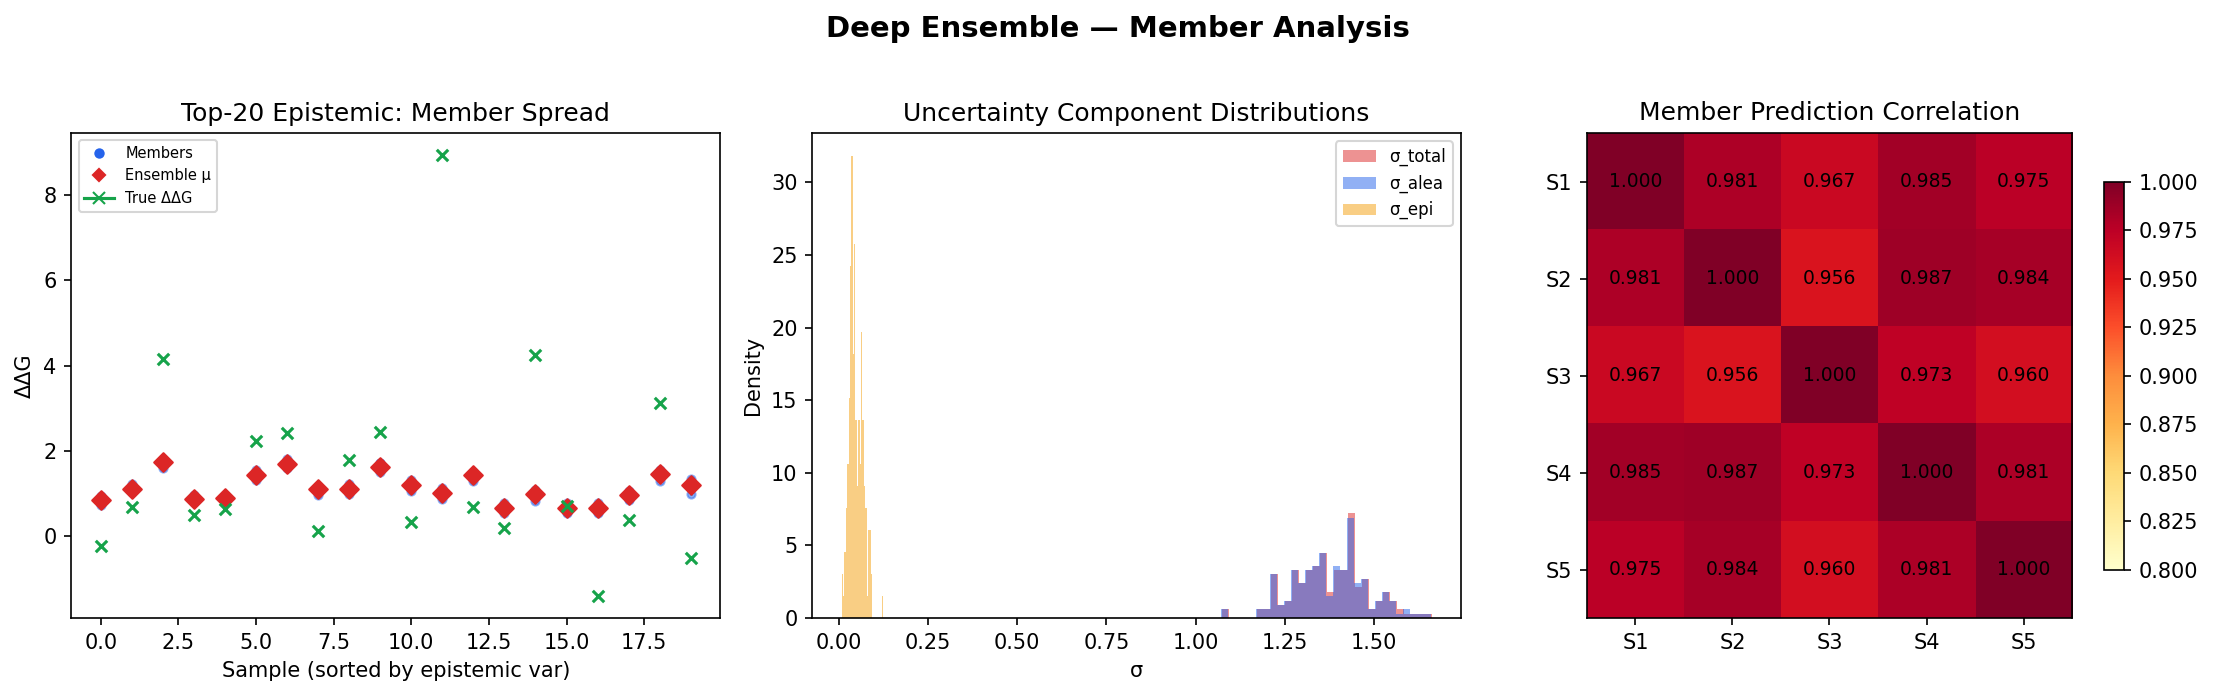

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Spread of member predictions for top-20 most uncertain ──
ax = axes[0]
top20_idx = np.argsort(epistemic)[-20:]
for rank, idx in enumerate(top20_idx):
    member_mus = all_mu[:, idx]
    ax.scatter([rank] * M, member_mus, c="#2563eb", s=15, alpha=0.5, zorder=2)
    ax.scatter(rank, mu_ens[idx], c="#dc2626", s=40, marker="D", zorder=3)
    ax.plot([rank, rank], [member_mus.min(), member_mus.max()],
            c="#93c5fd", lw=1.5, zorder=1)
    ax.scatter(rank, y_test[idx], c="#16a34a", s=30, marker="x", zorder=4, lw=1.5)
ax.set_xlabel("Sample (sorted by epistemic var)")
ax.set_ylabel("ΔΔG")
ax.set_title("Top-20 Epistemic: Member Spread")
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2563eb", ms=6, label="Members"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="#dc2626", ms=6, label="Ensemble μ"),
    Line2D([0], [0], marker="x", color="#16a34a", lw=1.5, ms=6, label="True ΔΔG"),
]
ax.legend(handles=legend_elements, fontsize=7, loc="upper left")

# ── σ distributions ──
ax = axes[1]
ax.hist(sigma_ens, bins=30, alpha=0.5, color="#dc2626", label="σ_total", density=True)
ax.hist(sigma_alea, bins=30, alpha=0.5, color="#2563eb", label="σ_alea", density=True)
ax.hist(sigma_epi, bins=30, alpha=0.5, color="#f59e0b", label="σ_epi", density=True)
ax.set_xlabel("σ")
ax.set_ylabel("Density")
ax.set_title("Uncertainty Component Distributions")
ax.legend(fontsize=8)

# ── Correlation matrix ──
ax = axes[2]
corr_matrix = np.corrcoef(all_mu)
im = ax.imshow(corr_matrix, vmin=0.8, vmax=1.0, cmap="YlOrRd")
for i in range(M):
    for j in range(M):
        ax.text(j, i, f"{corr_matrix[i,j]:.3f}", ha="center", va="center", fontsize=9)
ax.set_xticks(range(M))
ax.set_yticks(range(M))
ax.set_xticklabels([f"S{i+1}" for i in range(M)])
ax.set_yticklabels([f"S{i+1}" for i in range(M)])
ax.set_title("Member Prediction Correlation")
plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Deep Ensemble — Member Analysis",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "deep_ensemble_members.png")
plt.show()

## Save Ensemble Predictions

In [9]:
ensemble_df = pd.DataFrame({
    "y_true": y_test,
    "mu_ens": mu_ens,
    "sigma_total": sigma_ens,
    "sigma_aleatoric": sigma_alea,
    "sigma_epistemic": sigma_epi,
    "aleatoric_var": aleatoric,
    "epistemic_var": epistemic,
    "total_var": total_var,
    "abs_error": errors,
})
for i in range(M):
    ensemble_df[f"mu_m{i+1}"] = all_mu[i]
    ensemble_df[f"sigma_m{i+1}"] = all_sigma[i]

if len(test_meta) == len(y_test):
    ensemble_df = pd.concat([
        test_meta[["wtAA", "position", "mutAA", "rel_rsa"]].reset_index(drop=True),
        ensemble_df,
    ], axis=1)

ensemble_df.to_csv(FIG_DIR / "ensemble_predictions.csv", index=False)
print(f"Saved: {FIG_DIR / 'ensemble_predictions.csv'}")
print(f"Saved: {FIG_DIR / 'ensemble_summary.csv'}")
print(f"Saved: {FIG_DIR / 'deep_ensemble_analysis.png'}")
print(f"Saved: {FIG_DIR / 'deep_ensemble_members.png'}")
print("\nDone!")

Saved: figures/ensemble_predictions.csv
Saved: figures/ensemble_summary.csv
Saved: figures/deep_ensemble_analysis.png
Saved: figures/deep_ensemble_members.png

Done!
